## Preprocessing District GeoJSON

Extracting only the columns that we need.

In [1]:
import geopandas

### Arkansas Congressional District Path

In [2]:
path = '../../data/Arkansas/Arkansas_Congressional_Districts.json'

### GeoJson to geopandas

In [3]:
gdf = geopandas.read_file(path)
gdf

,objectid,district,st_area(sh,st_length(,geometry
0,409,2,1.408334e+10,8.158292e+05,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
1,410,4,5.981706e+10,1.689231e+06,"POLYGON ((517207.32159 3953177.73508, 517207.1..."
2,411,1,5.282824e+10,2.334336e+06,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
3,412,3,1.098867e+10,5.649465e+05,"POLYGON ((473744.18734 4039274.20057, 473495.9..."


In [4]:
gdf.columns

Index(['objectid', 'district', 'st_area(sh', 'st_length(', 'geometry'], dtype='str')

### Validating Geometry

<Axes: >

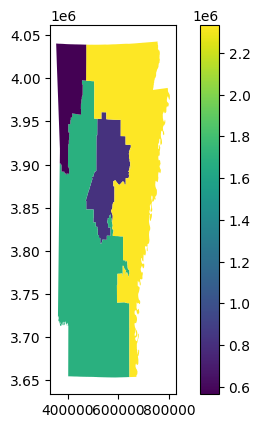

In [5]:
gdf.plot("st_length(", legend=True)

### Drop and Rename Columns

In [6]:
gdf = gdf.drop(columns=['objectid', 'st_area(sh', 'st_length('])
gdf

,district,geometry
0,2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
1,4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."
2,1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
3,3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."


In [7]:
gdf = gdf.sort_values(by='district')
gdf

,district,geometry
2,1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
0,2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
3,3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."
1,4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."


In [8]:
gdf['district'] = gdf['district'].map(lambda p: f'Congressional District {str(p)}')
gdf

,district,geometry
2,Congressional District 1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
0,Congressional District 2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
3,Congressional District 3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."
1,Congressional District 4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."


In [9]:
gdf = gdf.rename(columns={'district' : 'DISTRICT'})
gdf

,DISTRICT,geometry
2,Congressional District 1,"POLYGON ((643822.7059 3653027.88763, 645516.75..."
0,Congressional District 2,"POLYGON ((575778.91089 3833258.20114, 575777.0..."
3,Congressional District 3,"POLYGON ((473744.18734 4039274.20057, 473495.9..."
1,Congressional District 4,"POLYGON ((517207.32159 3953177.73508, 517207.1..."


### Convert CRS

In [10]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
gdf = gdf.set_crs("EPSG:26915", allow_override=True)
gdf = gdf.to_crs("EPSG:4326") 

In [12]:
print(gdf.crs)
print(gdf.head())

EPSG:4326
                   DISTRICT                                           geometry
2  Congressional District 1  POLYGON ((-91.46037 33.00621, -91.44224 33.006...
0  Congressional District 2  POLYGON ((-92.17319 34.63843, -92.1732 34.6395...
3  Congressional District 3  POLYGON ((-93.29317 36.49843, -93.29595 36.498...
1  Congressional District 4  POLYGON ((-92.80974 35.72242, -92.80975 35.722...


<Axes: >

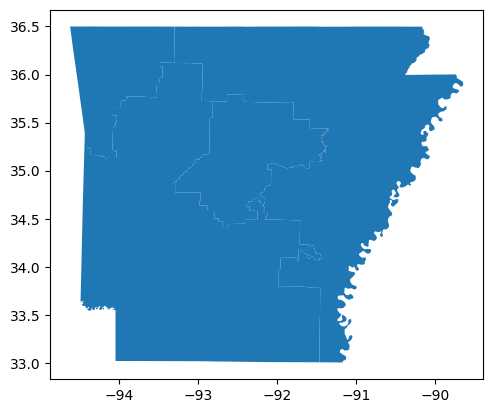

In [13]:
gdf.plot(None, legend=True)

### Save to Output

In [14]:
gdf.to_file("../output/Arkansas/Arkansas_Congressional_Districts.geojson", driver="GeoJSON")